In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape :", x_test.shape)


Training data shape: (60000, 28, 28)
Testing data shape : (10000, 28, 28)


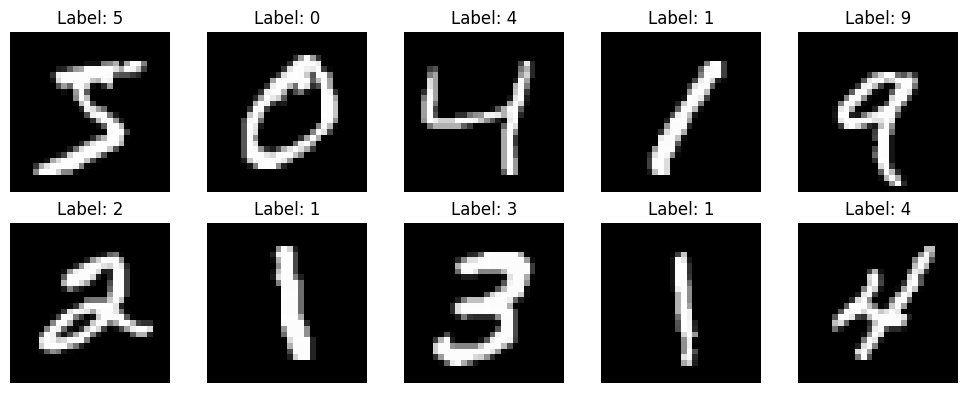

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0



In [ ]:
def create_model(lr):

    model = Sequential([
        Input(shape=(784,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
model = create_model(0.001)
model.summary()


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]

results = []

for lr in learning_rates:

    print("\nTraining with Learning Rate:", lr)

    model = create_model(lr)

    model.fit(
        x_train,
        y_train,
        epochs=10,
        batch_size=128,
        verbose=0
    )

    loss, acc = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    results.append([lr, acc, loss])


lr_df = pd.DataFrame(
    results,
    columns=['Learning Rate', 'Accuracy', 'Loss']
)

print("\nLearning Rate Results:")
print(lr_df)



Training with Learning Rate: 0.1

Training with Learning Rate: 0.01

Training with Learning Rate: 0.001

Training with Learning Rate: 0.0001

Learning Rate Results:
   Learning Rate  Accuracy      Loss
0         0.1000    0.4874  1.396742
1         0.0100    0.9738  0.133382
2         0.0010    0.9754  0.094304
3         0.0001    0.9612  0.133773


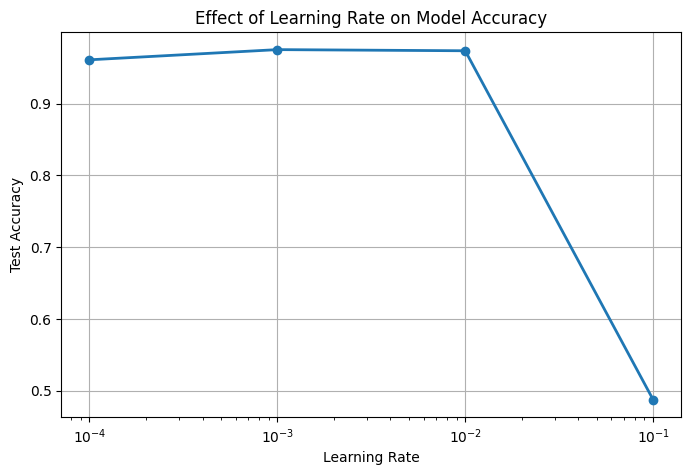

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    lr_df['Learning Rate'],
    lr_df['Accuracy'],
    marker='o',
    linewidth=2
)

plt.xscale('log')

plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy')
plt.title('Effect of Learning Rate on Model Accuracy')

plt.grid(True)

plt.show()

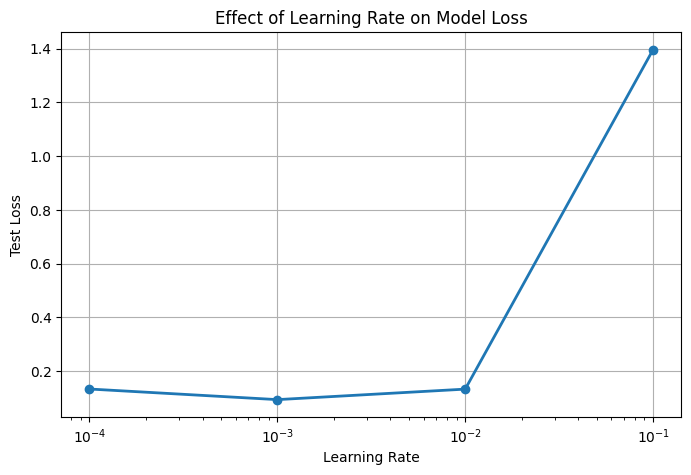

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    lr_df['Learning Rate'],
    lr_df['Loss'],
    marker='o',
    linewidth=2
)

plt.xscale('log')

plt.xlabel('Learning Rate')
plt.ylabel('Test Loss')
plt.title('Effect of Learning Rate on Model Loss')

plt.grid(True)

plt.show()


In [ ]:
epochs_list = [5, 10, 20, 30, 50]

epoch_results = []

for ep in epochs_list:

    print("\nTraining for", ep, "epochs")

    model = create_model(0.001)

    history = model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=ep,
        batch_size=128,
        verbose=0
    )

    loss, acc = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    epoch_results.append([ep, acc, loss])


epoch_df = pd.DataFrame(
    epoch_results,
    columns=['Epochs', 'Accuracy', 'Loss']
)

print("\nEpoch Results:")
print(epoch_df)


Training for 5 epochs

Training for 10 epochs

Training for 20 epochs

Training for 30 epochs

Training for 50 epochs

Epoch Results:
   Epochs  Accuracy      Loss
0       5    0.9715  0.090338
1      10    0.9722  0.099004
2      20    0.9761  0.108873
3      30    0.9816  0.104505
4      50    0.9784  0.128846


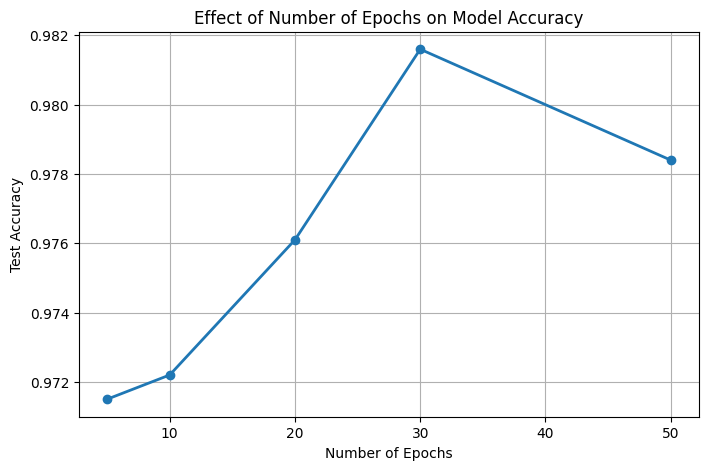

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epoch_df['Epochs'],
    epoch_df['Accuracy'],
    marker='o',
    linewidth=2
)

plt.xlabel('Number of Epochs')
plt.ylabel('Test Accuracy')
plt.title('Effect of Number of Epochs on Model Accuracy')

plt.grid(True)

plt.show()


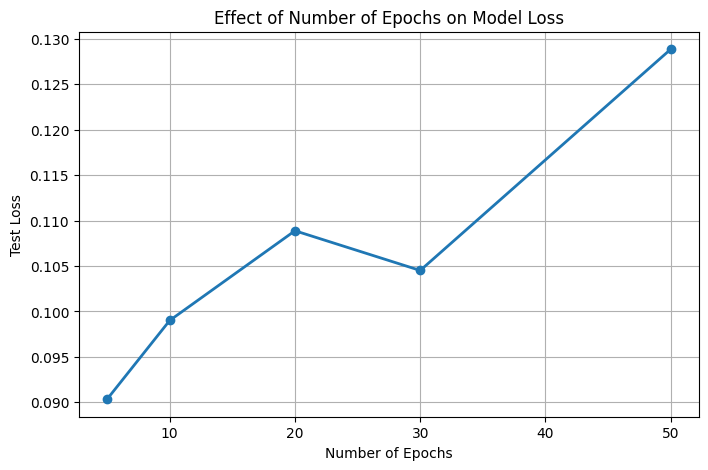

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epoch_df['Epochs'],
    epoch_df['Loss'],
    marker='o',
    linewidth=2
)

plt.xlabel('Number of Epochs')
plt.ylabel('Test Loss')
plt.title('Effect of Number of Epochs on Model Loss')

plt.grid(True)

plt.show()

In [ ]:
model = create_model(0.001)

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=128,
    verbose=1
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8985 - loss: 0.3625 - val_accuracy: 0.9512 - val_loss: 0.1753
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9548 - loss: 0.1529 - val_accuracy: 0.9618 - val_loss: 0.1291
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9685 - loss: 0.1085 - val_accuracy: 0.9666 - val_loss: 0.1126
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9759 - loss: 0.0828 - val_accuracy: 0.9677 - val_loss: 0.1098
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9808 - loss: 0.0656 - val_accuracy: 0.9707 - val_loss: 0.0950
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9840 - loss: 0.0527 - val_accuracy: 0.9707 - val_loss: 0.0949
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9869 - loss: 0.0431 - val_accuracy: 0.9723 - val_loss: 0.0926
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9901 - loss: 0.0338 - val_accuracy: 0.

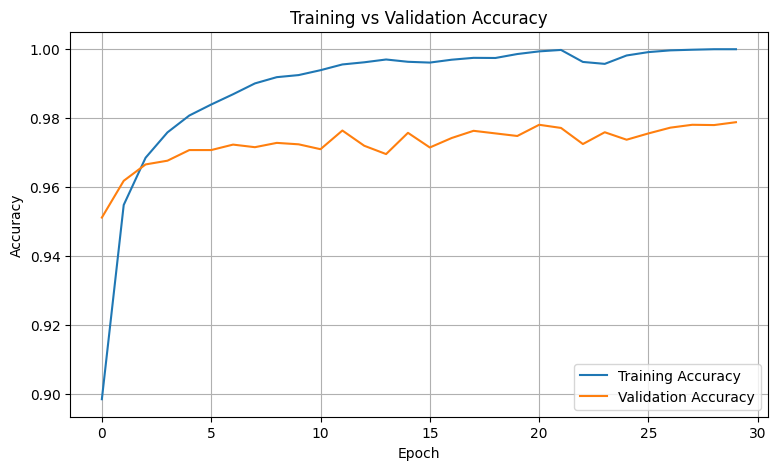

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.title('Training vs Validation Accuracy')

plt.legend()
plt.grid(True)

plt.show()



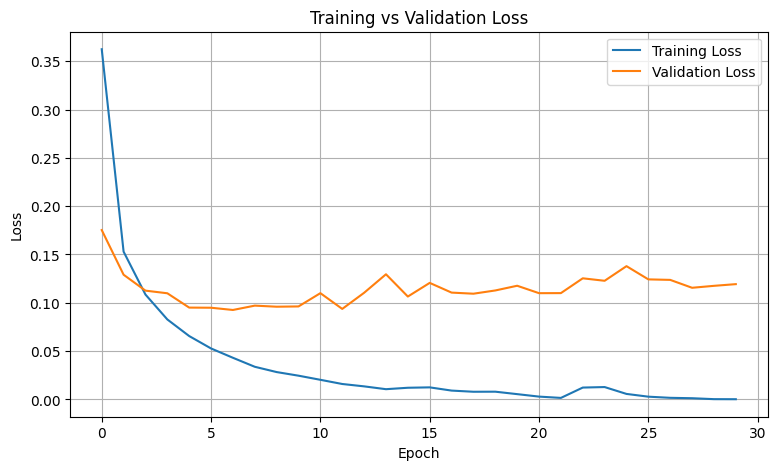

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Training vs Validation Loss')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nFinal Model Results")
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)


Final Model Results
Test Accuracy: 0.979200005531311
Test Loss: 0.10522730648517609


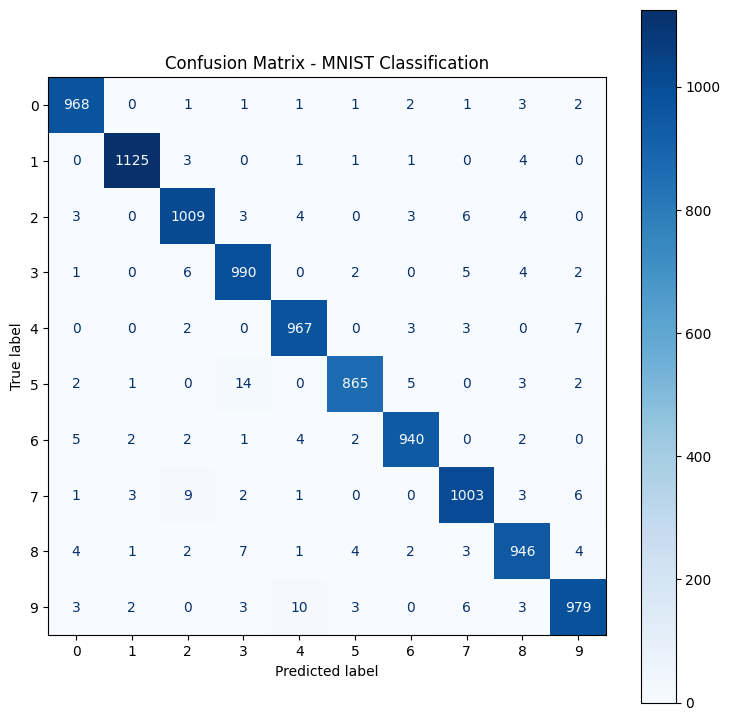

In [ ]:
predictions = model.predict(x_test, verbose=0)

y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

fig, ax = plt.subplots(figsize=(9, 9))

disp.plot(
    ax=ax,
    cmap='Blues',
    values_format='d'
)

plt.title('Confusion Matrix - MNIST Classification')

plt.show()

In [ ]:
# ==================================================
# CONFUSION MATRIX HEATMAP
# ==================================================

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix Heatmap')

plt.show()

NameError: name 'sns' is not defined

<Figure size 1000x800 with 0 Axes>

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(15):

    plt.subplot(3, 5, i + 1)

    image = x_test[i].reshape(28, 28)

    plt.imshow(image, cmap='gray')

    plt.title(
        "Actual: " + str(y_test[i]) +
        "\nPredicted: " + str(y_pred[i])
    )

    plt.axis('off')

plt.tight_layout()

plt.show()